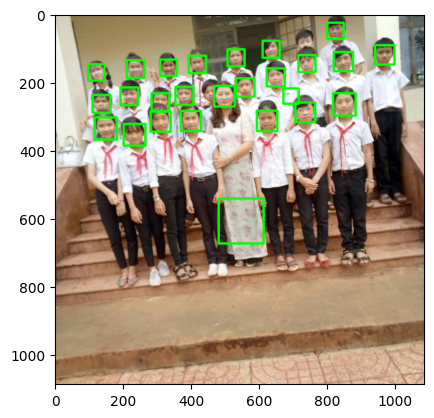

In [9]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("img4.jpg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
stop_data = cv2.CascadeClassifier('haarcascade_frontalface_alt.xml')
found = stop_data.detectMultiScale(img_gray,minSize =(20, 20))
amount_found = len(found)

if amount_found != 0:
    for (x, y, width, height) in found:
        cv2.rectangle(img_rgb, (x, y),
                      (x + height, y + width),
                      (0, 255, 0), 5)
plt.imshow(img_rgb)


2. Sử dụng các tham khảo và hình ảnh trên, có thể sử dụng thêm các ảnh tập thể, kỷ yếu khác để nhận diện: Nụ cười, tai, mắt, mũi, miệng, … của người trong bức ảnh. 

phát hiện được 19 khuôn mặt trong ảnh


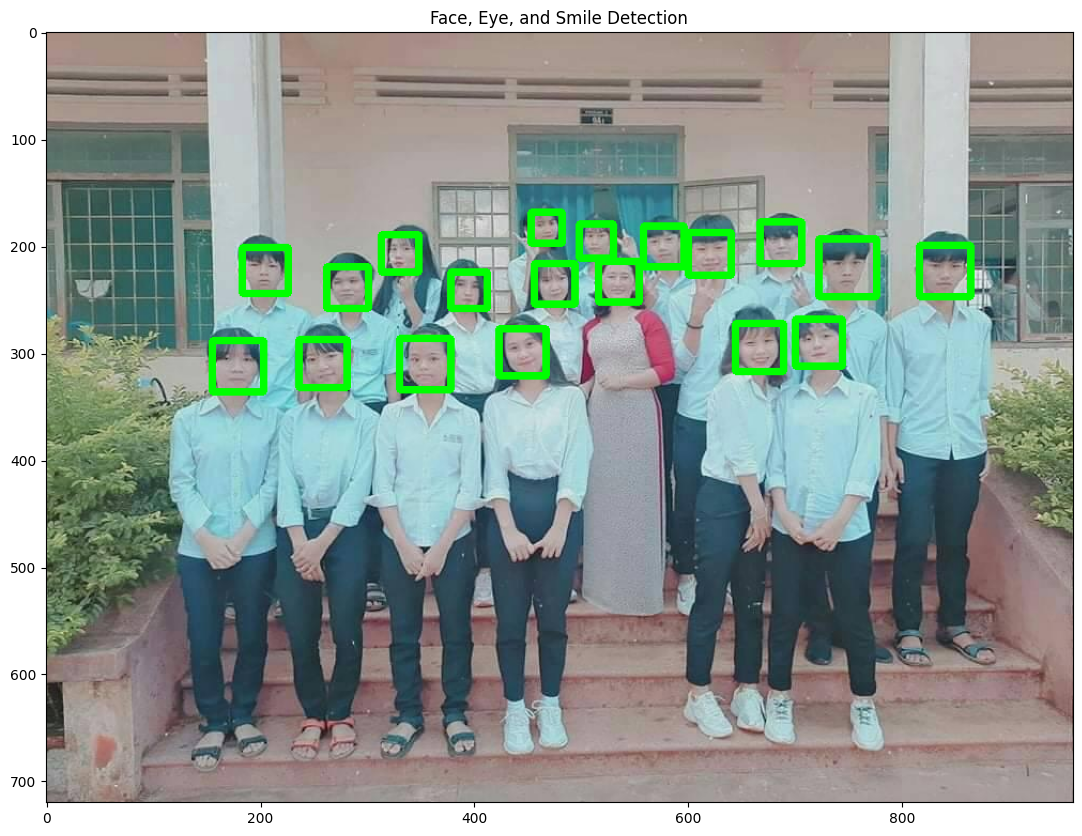

In [11]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh (theo tên file của bạn)
img = cv2.imread("img3.jpg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1. Khởi tạo các Cascade 
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_alt.xml')
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier('haarcascade_smile.xml')
# 2. Nhận diện khuôn mặt 
faces = face_cascade.detectMultiScale(img_gray, minSize=(20, 20))

print(f"phát hiện được {len(faces)} khuôn mặt trong ảnh")

if len(faces) != 0:
    for (x, y, width, height) in faces:
        # vẽ khung màu Xanh lá cho Khuôn mặt
        cv2.rectangle(img_rgb, (x, y), (x + width, y + height), (0, 255, 0), 5)
        # 3. Tạo vùng ROI (chỉ lấy phần hình ảnh bên trong khuôn mặt)
        roi_gray = img_gray[y:y+height, x:x+width]
        roi_rgb = img_rgb[y:y+height, x:x+width]
        #nhận diện Mắt
        eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=5)
        for (ex, ey, ew, eh) in eyes:
            # Vẽ khung màu Đỏ cho Mắt
            cv2.rectangle(roi_rgb, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 2)
            
        # nhận diện Nụ cười
        smiles = smile_cascade.detectMultiScale(roi_gray, scaleFactor=1.7, minNeighbors=20)
        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_rgb, (sx, sy), (sx + sw, sy + sh), (255, 255, 0), 2)
#hiển thị kết quả ra màn hình
plt.figure(figsize=(15, 10))
plt.imshow(img_rgb)
plt.title('Face, Eye, and Smile Detection')
plt.show()